In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

(100, 2)
(100,)


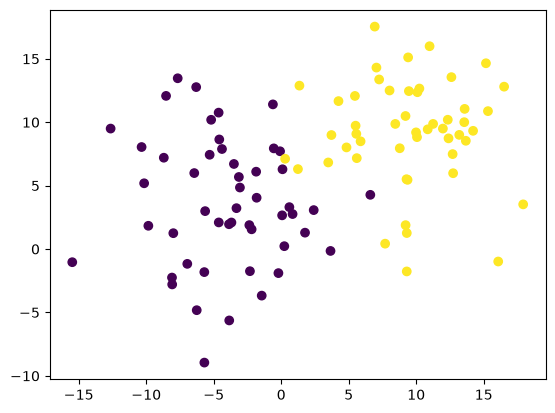

In [2]:
data = make_blobs(n_samples=100,n_features=2,centers=2,cluster_std=4)
X = data[0]
y = data[1]
print(X.shape)
print(y.shape)
plt.scatter(X[:,0],X[:,1],c=y)

# Neural Network

In [83]:
class NeuralNetwork:
    def __init__(self,layers:list,activation:str,output_activation:str):
        self.layers = layers

        self.weights = []
        self.bias = []
        self.loss = []

        for index in range(len(self.layers)-1):
            self.weights.append(np.random.random((self.layers[index],self.layers[index+1])))
            self.bias.append(np.random.random((1,self.layers[index+1])))
        
        print(self.weights)
        print(self.bias)

    def forward_propogation(self):
        self.input = self.X
        
        for i in range(len(self.layers)-1):
            if(i==len(self.layers)-1):
                output = np.matmul(self.input,self.weights[i]) + self.bias[i]
            else:
                output = self.tanh(np.matmul(self.input,self.weights[i]) + self.bias[i])
            self.layer_output.append(output)
            self.input = output
        proba = self.sigmoid(output)
        return proba

    def sigmoid(self,x):
        return 1/(1+np.exp(-x))

    def tanh(self,x):
        return np.tanh(x)

    def predict(self,points,threshold = 0.5):
        return np.array([1 if x> threshold else 0 for x in points])

    def fit(self,X,y, n_iter = 1000, lr = 0.01):
        self.X = X
        self.y = y.reshape(-1,1) 
        for iter in range(n_iter):
            self.layer_output = [self.X]
            self.yp = self.forward_propogation().reshape(-1,1)
            loss = np.sum(-self.y*np.log(np.clip(self.yp,1e-8,1-1e-8)) - (1-self.y)*(np.log(np.clip(1-self.yp,1e-8,1-1e-8))))
            self.loss.append(loss/len(self.y))
            for l in range(len(self.layers)-1,0,-1):
                if(l==len(self.layers)-1):
                    delta = self.yp - self.y
                else:
                    # delta = (1-self.layer_output[l]@self.layer_output[l].T)*self.weights[l+1]@delta_l1.T
                    delta = delta_l1@self.weights[l].T*(1-self.layer_output[l]**2)

                delta_l1 = delta
                self.weights[l-1] = self.weights[l-1] - lr * self.layer_output[l-1].T@delta
                self.bias[l-1] = self.bias[l-1] - lr * delta
        return self.predict(self.yp)
        


In [84]:
nn = NeuralNetwork([X.shape[1],5,1],"tanh","sigmoid")
predict = nn.fit(X,y)

[array([[0.54031852, 0.00391226, 0.64017487, 0.57106385, 0.26604025],
       [0.68684946, 0.15212574, 0.39780727, 0.8115049 , 0.48412127]]), array([[0.26846851],
       [0.87257915],
       [0.27042842],
       [0.02775141],
       [0.67504378]])]
[array([[0.49014078, 0.00448632, 0.44612527, 0.91808089, 0.80110136]]), array([[0.73401733]])]


In [85]:
np.sum(y == predict)/len(y)

np.float64(0.89)

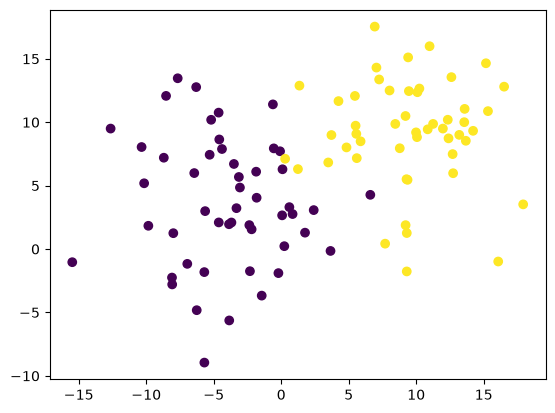

In [86]:
plt.scatter(X[:,0],X[:,1],c=y)


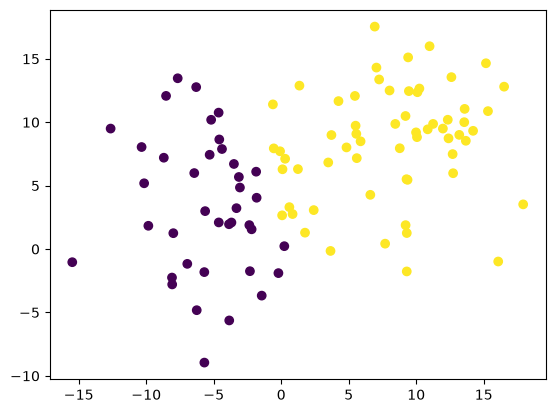

In [87]:
plt.scatter(X[:,0],X[:,1],c=predict)

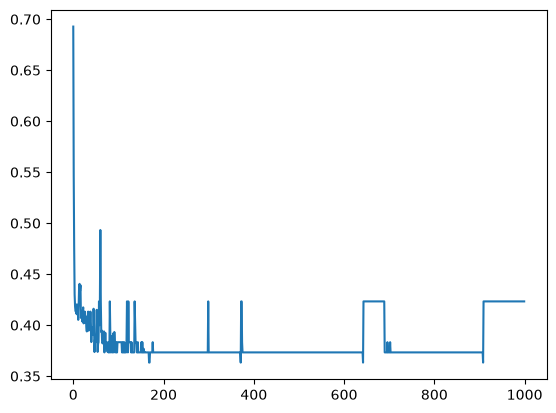

In [88]:
plt.plot(nn.loss)